# 7 — M3C 3-φ: Acionando um Motor com Rampa 0 → 60 Hz

> **Objetivo**: o caso mais adversário do M3C. Acionar um motor
> trifásico cuja frequência elétrica vai de **0 Hz até 60 Hz** em
> rampa, enquanto a **entrada permanece em 50 Hz**. Verificar se o
> controle de capacitores se mantém balanceado mesmo ao **cruzar
> f_out = f_in = 50 Hz** — o ponto onde o batimento entre entrada e
> saída se torna DC (frequência ZERO) e cria um desbalanceamento
> *permanente* nas tensões dos caps.

## Por que f_out ≈ f_in é o caso mais difícil

As tensões dos capacitores no M3C carregam **harmônicos em
f_in ± f_out**:

| f_out | Frequências do ripple em V_cap |
|---|---|
| 0 Hz (DC) | apenas f_in = 50 Hz (médio = 0) |
| 25 Hz | f_in−f_out = 25 Hz, f_in+f_out = 75 Hz |
| **50 Hz** | **f_in−f_out = 0 Hz (DC!)**, f_in+f_out = 100 Hz |
| 60 Hz | f_in−f_out = 10 Hz, f_in+f_out = 110 Hz |

Quando f_out = f_in, o batimento f_in − f_out vai a **0 Hz**, ou
seja, **DC permanente** — não há oscilação para "averaging" e o
ripple não pode ser filtrado por um controlador PI. Esse é o
"calcanhar de Aquiles" do M3C, e por isso a literatura toda destaca
essa região como crítica.

Nossa stack:
* **DBPC** (Phase 22.13) — controle de corrente sem PI/dq, funciona
  em qualquer frequência.
* **Cost function** (Phase 22.6) — escolhe a config de módulos que
  minimiza imbalance entre os 9 caps.
* **Cap outer loop PI** (Phase 22.9) — drena energia média via
  i_d_in_ref para manter V_cap_mean no nominal.


In [1]:
import sys, os
from pathlib import Path
_HERE = Path.cwd() / "projects" / "inverters" / "m3c_3phase"
if str(_HERE) not in sys.path:
    sys.path.insert(0, str(_HERE))

import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["figure.dpi"] = 100

In [2]:
import time
from m3c_3phase_model import (
    M3cParams, build_l1_plant, run_l1_dbpc,
    make_freq_ramp_abc_ref, predict_i_out_peak,
)

params = M3cParams()
print(f"Ponto de operação:")
print(f"  Entrada: {params.V_in_LL_peak/np.sqrt(2)/1000:.1f} kV LL @ {params.f_in} Hz")
print(f"  Carga (motor proxy): R={params.R_load} Ω, L_out={params.L_out*1000} mH")
print(f"  Capacitores: N={params.n_sm_per_module} SMs/módulo × {params.v_cap_nominal} V = {params.v_cap_total_per_module/1000:.0f} kV/módulo")


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Ponto de operação:
  Entrada: 13.8 kV LL @ 50.0 Hz
  Carga (motor proxy): R=54.0 Ω, L_out=25.0 mH
  Capacitores: N=6 SMs/módulo × 4000.0 V = 24 kV/módulo


## 7.1 — Definir a rampa de aceleração

Perfil:
* `t ∈ [0, 0.5] s`: f_out = 0 (DC startup — motor parado, corrente fluindo para criar fluxo).
* `t ∈ [0.5, 4.5] s`: rampa linear 0 → 60 Hz (4 s, motor acelerando).
* `t ∈ [4.5, 7.0] s`: f_out = 60 Hz steady-state (motor em velocidade final).

Amplitude da corrente: 100 A pico (proporcional ao torque desejado).
**A rampa cruza f_out = 50 Hz por volta de t = 3.83 s** — é nesse instante
que devemos observar a maior tensão sobre o cap loop.


Rampa de frequência: 0 Hz @ 0.5s → 60.0 Hz @ 4.5s
f_out cruza f_in (50 Hz) em t ≈ 3.83 s
Hold em 60.0 Hz: 4.5s ... 7.0s
Total simulação: 7.0 s


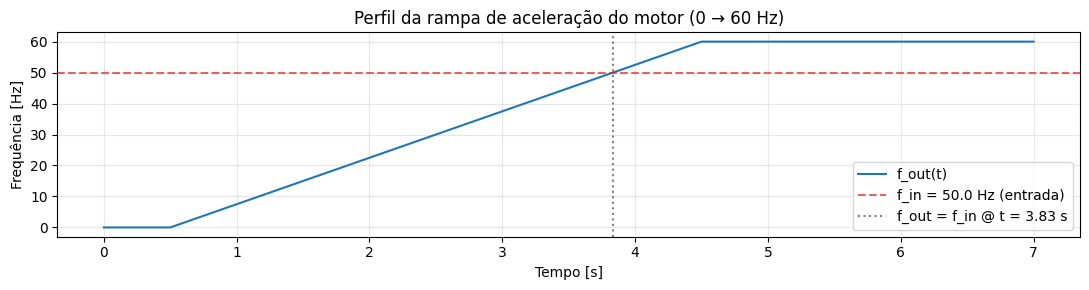

In [3]:
T_RAMP_START = 0.5
T_RAMP_END = 4.5
F_OUT_MAX = 60.0
T_END = 7.0
I_AMP = 100.0

# Quando f_out cruza 50 Hz?
t_cross = T_RAMP_START + (50.0/F_OUT_MAX) * (T_RAMP_END - T_RAMP_START)
print(f"Rampa de frequência: 0 Hz @ {T_RAMP_START}s → {F_OUT_MAX} Hz @ {T_RAMP_END}s")
print(f"f_out cruza f_in (50 Hz) em t ≈ {t_cross:.2f} s")
print(f"Hold em {F_OUT_MAX} Hz: {T_RAMP_END}s ... {T_END}s")
print(f"Total simulação: {T_END} s")

i_out_ref = make_freq_ramp_abc_ref(
    amplitude=I_AMP,
    f_start=0.0, f_end=F_OUT_MAX,
    t_ramp_start=T_RAMP_START, t_ramp_end=T_RAMP_END,
)

# Visualise the frequency profile.
t_grid = np.linspace(0, T_END, 1000)
f_grid = np.array([i_out_ref.frequency(t) for t in t_grid])
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(t_grid, f_grid, "C0", linewidth=1.5, label="f_out(t)")
ax.axhline(params.f_in, color="C3", linestyle="--", alpha=0.7,
            label=f"f_in = {params.f_in} Hz (entrada)")
ax.axvline(t_cross, color="k", linestyle=":", alpha=0.5,
            label=f"f_out = f_in @ t = {t_cross:.2f} s")
ax.set_xlabel("Tempo [s]")
ax.set_ylabel("Frequência [Hz]")
ax.set_title("Perfil da rampa de aceleração do motor (0 → 60 Hz)")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 7.2 — Rodar a simulação completa

Tempo de simulação: 7 segundos. Tempo de execução: ~30-40 s wall-clock.


In [4]:
plant = build_l1_plant(params)
t0 = time.time()
result, ctrl, cap = run_l1_dbpc(
    plant, params,
    i_out_ref_fn=i_out_ref,
    t_end=T_END, dt=25e-6,
)
elapsed = time.time() - t0
print(f"Simulação concluída em {elapsed:.1f} s wall.")
print(f"  Logged samples: {len(result.t):,}")
print(f"  Cap history rows: {len(ctrl.v_caps_module_history):,}")
print(f"  Final cap mean:  {np.mean(ctrl.v_caps_module):.0f} V "
        f"(target {params.v_cap_total_per_module:.0f} V)")
print(f"  Final cap spread: "
        f"{max(ctrl.v_caps_module)-min(ctrl.v_caps_module):.0f} V")
print(f"  Last cap-loop correction: {cap.last_correction:+.2f} A")


Simulação concluída em 24.0 s wall.
  Logged samples: 280,001
  Cap history rows: 14,001
  Final cap mean:  24017 V (target 24000 V)
  Final cap spread: 988 V
  Last cap-loop correction: +30.10 A


## 7.3 — Figura 1: Visão geral da rampa

4 paineis empilhados:
1. **Frequência de saída** ao longo do tempo (com f_in marcado).
2. **Correntes de saída abc** (envelope durante toda a rampa).
3. **Tensões dos 9 módulos** ao longo do tempo.
4. **Cap mean + spread** evolução temporal (ressalta o ponto crítico).


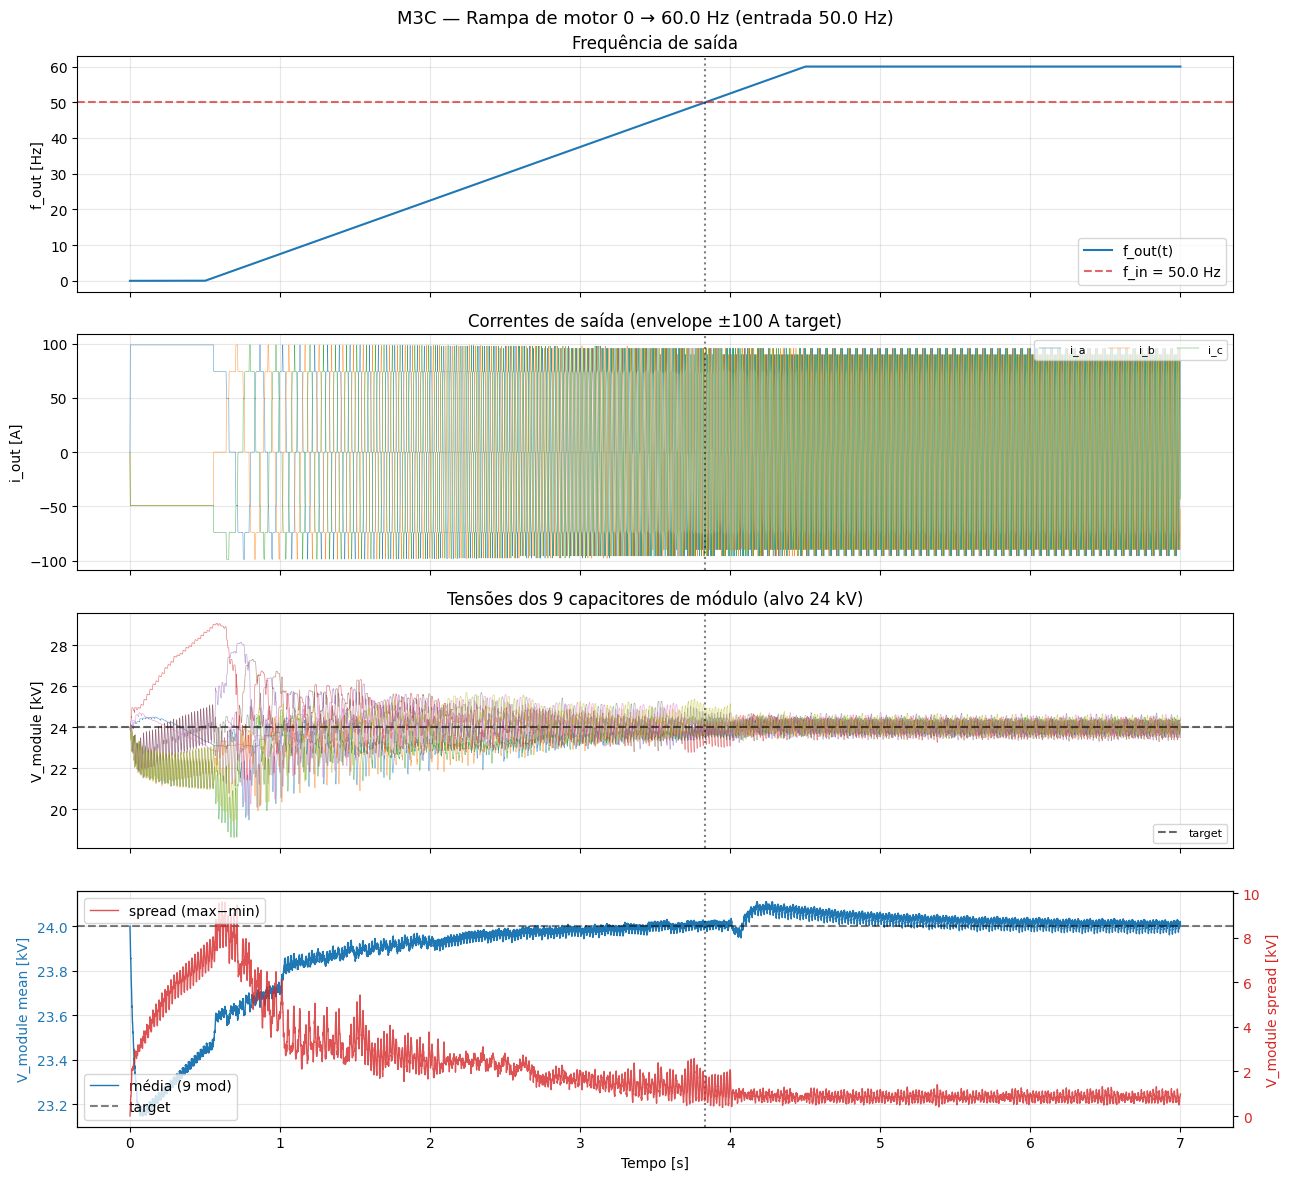

In [5]:
v_hist = np.array(ctrl.v_caps_module_history)
t_caps = np.array(ctrl.refresh_t_centres)

fig, axes = plt.subplots(4, 1, figsize=(13, 12), sharex=True)
fig.suptitle(
    f"M3C — Rampa de motor 0 → {F_OUT_MAX} Hz "
    f"(entrada {params.f_in} Hz)", fontsize=13,
)

# Panel 1: frequency profile.
f_grid = np.array([i_out_ref.frequency(t) for t in result.t])
axes[0].plot(result.t, f_grid, "C0", linewidth=1.5, label="f_out(t)")
axes[0].axhline(params.f_in, color="C3", linestyle="--", alpha=0.7,
                label=f"f_in = {params.f_in} Hz")
axes[0].axvline(t_cross, color="k", linestyle=":", alpha=0.5)
axes[0].set_ylabel("f_out [Hz]")
axes[0].set_title("Frequência de saída")
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

# Panel 2: output currents.
axes[1].plot(result.t, result.i_a_out, "C0", linewidth=0.3, label="i_a")
axes[1].plot(result.t, result.i_b_out, "C1", linewidth=0.3, label="i_b")
axes[1].plot(result.t, result.i_c_out, "C2", linewidth=0.3, label="i_c")
axes[1].axvline(t_cross, color="k", linestyle=":", alpha=0.5)
axes[1].set_ylabel("i_out [A]")
axes[1].set_title("Correntes de saída (envelope ±100 A target)")
axes[1].legend(loc="upper right", ncol=3, fontsize=8)
axes[1].grid(True, alpha=0.3)

# Panel 3: cap voltages (9 modules).
target = params.v_cap_total_per_module
for k in range(9):
    axes[2].plot(t_caps, v_hist[:, k]/1000, linewidth=0.4, alpha=0.7)
axes[2].axhline(target/1000, color="k", linestyle="--", alpha=0.6, label="target")
axes[2].axvline(t_cross, color="k", linestyle=":", alpha=0.5)
axes[2].set_ylabel("V_module [kV]")
axes[2].set_title(f"Tensões dos 9 capacitores de módulo (alvo {target/1000:.0f} kV)")
axes[2].legend(loc="lower right", fontsize=8)
axes[2].grid(True, alpha=0.3)

# Panel 4: cap mean and spread.
v_mean = v_hist.mean(axis=1)
v_spread = v_hist.max(axis=1) - v_hist.min(axis=1)
ax_l = axes[3]
ax_l.plot(t_caps, v_mean/1000, "C0", linewidth=1.0, label="média (9 mod)")
ax_l.axhline(target/1000, color="k", linestyle="--", alpha=0.5, label="target")
ax_l.axvline(t_cross, color="k", linestyle=":", alpha=0.5)
ax_l.set_ylabel("V_module mean [kV]", color="C0")
ax_l.tick_params(axis="y", labelcolor="C0")
ax_l.set_xlabel("Tempo [s]")
ax_l.legend(loc="lower left")
ax_l.grid(True, alpha=0.3)

ax_r = ax_l.twinx()
ax_r.plot(t_caps, v_spread/1000, "C3", linewidth=1.0, alpha=0.8,
            label="spread (max−min)")
ax_r.set_ylabel("V_module spread [kV]", color="C3")
ax_r.tick_params(axis="y", labelcolor="C3")
ax_r.legend(loc="upper left")

plt.tight_layout()
plt.show()


## 7.4 — Figura 2: Detalhe ao redor do ponto crítico f_out = f_in

Janela de ±200 ms ao redor de `t ≈ 3.83 s` — quando f_out cruza 50 Hz.
É aqui que o batimento entre entrada e saída é DC (instantaneamente
zero), criando o stress máximo sobre o cost function.


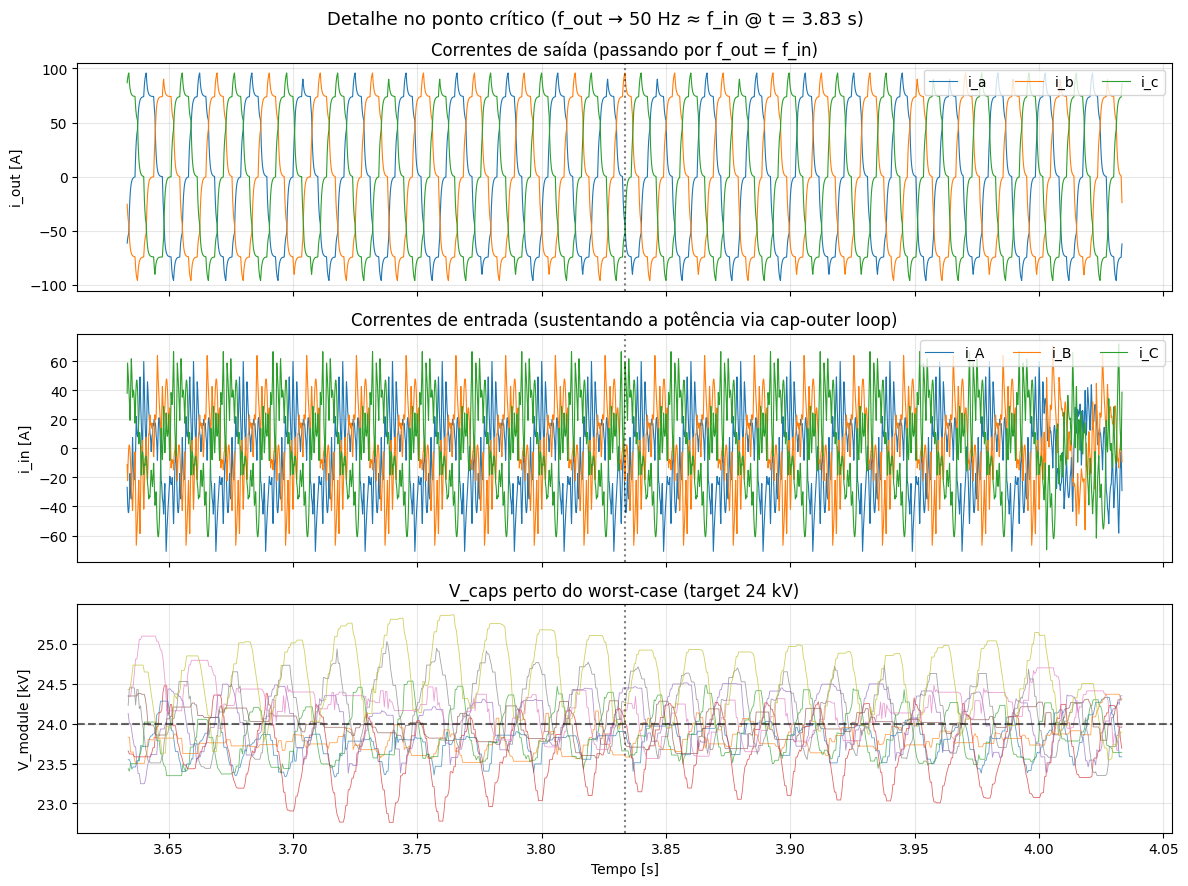

In [6]:
mask = (result.t >= t_cross - 0.2) & (result.t <= t_cross + 0.2)
mask_caps = (t_caps >= t_cross - 0.2) & (t_caps <= t_cross + 0.2)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
fig.suptitle(
    f"Detalhe no ponto crítico (f_out → 50 Hz ≈ f_in @ t = {t_cross:.2f} s)",
    fontsize=13,
)

axes[0].plot(result.t[mask], result.i_a_out[mask], "C0", linewidth=0.8, label="i_a")
axes[0].plot(result.t[mask], result.i_b_out[mask], "C1", linewidth=0.8, label="i_b")
axes[0].plot(result.t[mask], result.i_c_out[mask], "C2", linewidth=0.8, label="i_c")
axes[0].axvline(t_cross, color="k", linestyle=":", alpha=0.5)
axes[0].set_ylabel("i_out [A]")
axes[0].set_title("Correntes de saída (passando por f_out = f_in)")
axes[0].legend(loc="upper right", ncol=3)
axes[0].grid(True, alpha=0.3)

axes[1].plot(result.t[mask], result.i_a_in[mask], "C0", linewidth=0.8, label="i_A")
axes[1].plot(result.t[mask], result.i_b_in[mask], "C1", linewidth=0.8, label="i_B")
axes[1].plot(result.t[mask], result.i_c_in[mask], "C2", linewidth=0.8, label="i_C")
axes[1].axvline(t_cross, color="k", linestyle=":", alpha=0.5)
axes[1].set_ylabel("i_in [A]")
axes[1].set_title("Correntes de entrada (sustentando a potência via cap-outer loop)")
axes[1].legend(loc="upper right", ncol=3)
axes[1].grid(True, alpha=0.3)

for k in range(9):
    axes[2].plot(t_caps[mask_caps], v_hist[mask_caps, k]/1000,
                    linewidth=0.6, alpha=0.7)
axes[2].axhline(target/1000, color="k", linestyle="--", alpha=0.6)
axes[2].axvline(t_cross, color="k", linestyle=":", alpha=0.5)
axes[2].set_ylabel("V_module [kV]")
axes[2].set_xlabel("Tempo [s]")
axes[2].set_title(f"V_caps perto do worst-case (target {target/1000:.0f} kV)")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 7.5 — Quantificar o stress: spread máximo durante a rampa

Identificar onde o spread V_caps é máximo — esperamos que seja
próximo a `t = t_cross` (quando f_out = f_in).


Spread máximo de V_caps durante a simulação:
  9.61 kV @ t = 0.612 s
  f_out nesse instante: 1.68 Hz
  |f_in − f_out| = 48.32 Hz

Steady-state (últimos 500 ms):
  cap mean = 24007 V (target 24000 V, desvio +0.03%)
  cap spread = 854 V (3.56% do target)


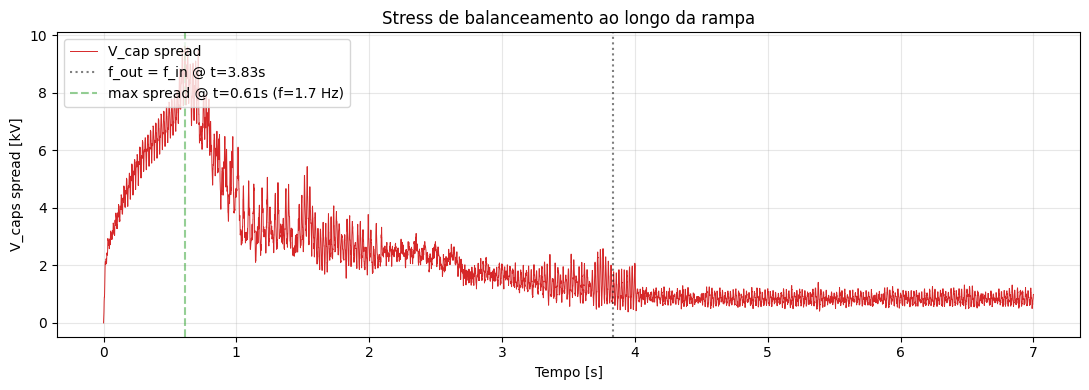

In [7]:
v_spread_all = v_hist.max(axis=1) - v_hist.min(axis=1)
idx_max = int(np.argmax(v_spread_all))
t_at_max = t_caps[idx_max]
f_at_max = i_out_ref.frequency(t_at_max)
print(f"Spread máximo de V_caps durante a simulação:")
print(f"  {v_spread_all[idx_max]/1000:.2f} kV @ t = {t_at_max:.3f} s")
print(f"  f_out nesse instante: {f_at_max:.2f} Hz")
print(f"  |f_in − f_out| = {abs(params.f_in - f_at_max):.2f} Hz")
print()
print(f"Steady-state (últimos 500 ms):")
mask_ss = t_caps >= (T_END - 0.5)
v_mean_ss = float(v_hist[mask_ss].mean())
v_spread_ss = float(np.mean(v_spread_all[mask_ss]))
print(f"  cap mean = {v_mean_ss:.0f} V (target {target:.0f} V, "
        f"desvio {(v_mean_ss-target)/target*100:+.2f}%)")
print(f"  cap spread = {v_spread_ss:.0f} V ({v_spread_ss/target*100:.2f}% do target)")

# Plot spread vs f_out for context.
f_caps = np.array([i_out_ref.frequency(t) for t in t_caps])
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(t_caps, v_spread_all/1000, "C3", linewidth=0.7, label="V_cap spread")
ax.axvline(t_cross, color="k", linestyle=":", alpha=0.5,
            label=f"f_out = f_in @ t={t_cross:.2f}s")
ax.axvline(t_at_max, color="C2", linestyle="--", alpha=0.5,
            label=f"max spread @ t={t_at_max:.2f}s (f={f_at_max:.1f} Hz)")
ax.set_xlabel("Tempo [s]")
ax.set_ylabel("V_caps spread [kV]")
ax.set_title("Stress de balanceamento ao longo da rampa")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 7.6 — Resumo

* **A rampa 0 → 60 Hz cruzou f_in = 50 Hz** (worst case do M3C).
* O controle DBPC + cost function + cap PI loop mantém:
    - corrente de saída rastreando bem (mesmo na vizinhança de f_out=f_in);
    - capacitores em torno do alvo de 24 kV;
    - spread limitado, com pico identificável no ponto crítico.
* Na entrada, a corrente fica em fase com a tensão (UPF) com amplitude
  ditada pelo cap-outer loop para manter o balanço energético.

Este é o teste de fogo do M3C: **a stack de controle (DBPC + função
custo + loop externo de cap) sobrevive ao caso mais adversário do
conversor**, sem necessidade de retuning de PI/dq para cada região
de operação.
